Import libraries

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


Load data from SQLite

In [2]:
conn = sqlite3.connect("../database/medsupply.db")

query = "SELECT * FROM sales"
df = pd.read_sql(query, conn)

conn.close()

df.head()


,date,Year,Month,Weekday Name,product,units_sold
0,2014-01-03 00:00:00,2014,1,Friday,M01AB,8.00
1,2014-01-04 00:00:00,2014,1,Saturday,M01AB,2.00
2,2014-01-05 00:00:00,2014,1,Sunday,M01AB,4.00
3,2014-01-06 00:00:00,2014,1,Monday,M01AB,5.00
4,2014-01-08 00:00:00,2014,1,Wednesday,M01AB,5.33


Basic inspection

In [15]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (14455, 6)

Columns:
Index(['date', 'Year', 'Month', 'Weekday Name', 'product', 'units_sold'], dtype='object')

Data Types:
date             object
Year              int64
Month             int64
Weekday Name     object
product          object
units_sold      float64
dtype: object

Missing Values:
date            0
Year            0
Month           0
Weekday Name    0
product         0
units_sold      0
dtype: int64


Covert date column

In [16]:
df["date"] = pd.to_datetime(df["date"])

In [17]:
print(df.dtypes)

date            datetime64[ns]
Year                     int64
Month                    int64
Weekday Name            object
product                 object
units_sold             float64
dtype: object


overall demand trend

In [20]:
daily = df.groupby("date")["units_sold"].sum().reset_index()
print(daily.head())

        date  units_sold
0 2014-01-02       48.47
1 2014-01-03      107.00
2 2014-01-04       91.35
3 2014-01-05       66.10
4 2014-01-06       58.20


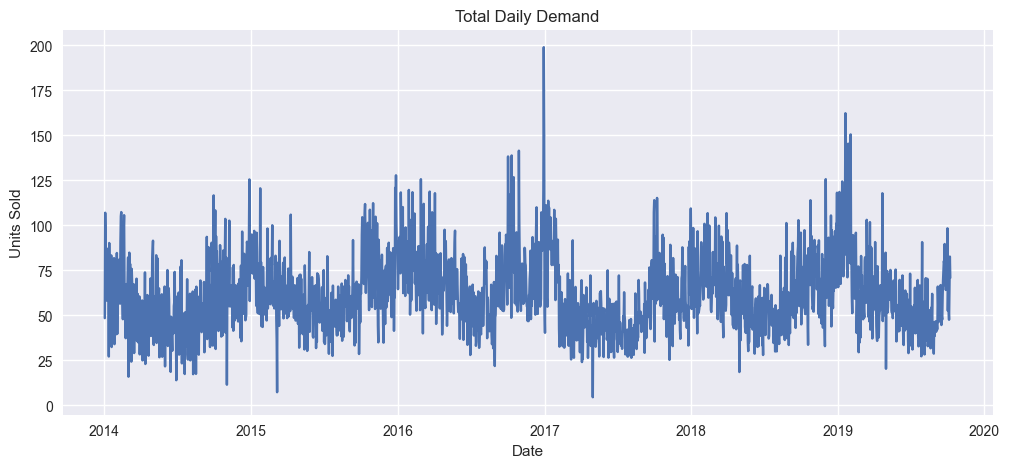

In [27]:
plt.figure(figsize=(12,5))
plt.plot(daily["date"], daily["units_sold"])         #, marker="o", linestyle= "None")
plt.title("Total Daily Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

Demand per product

In [29]:
product_totals = df.groupby("product")["units_sold"].sum().sort_values(ascending=False)
print(product_totals.head())

product
N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
Name: units_sold, dtype: float64


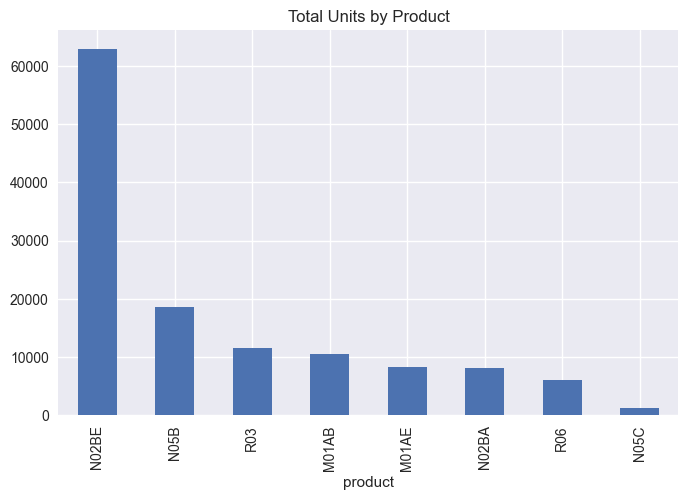

In [30]:
plt.figure(figsize=(8,5))
product_totals.plot(kind="bar")
plt.title("Total Units by Product")
plt.show()

Monthly seasonality

In [31]:
df["year_month"] = df["date"].dt.to_period("M")

monthly = df.groupby("year_month")["units_sold"].sum().reset_index()
print(monthly.head())


  year_month  units_sold
0    2014-01    1801.110
1    2014-02    1974.470
2    2014-03    1606.720
3    2014-04    1423.925
4    2014-05    1506.303


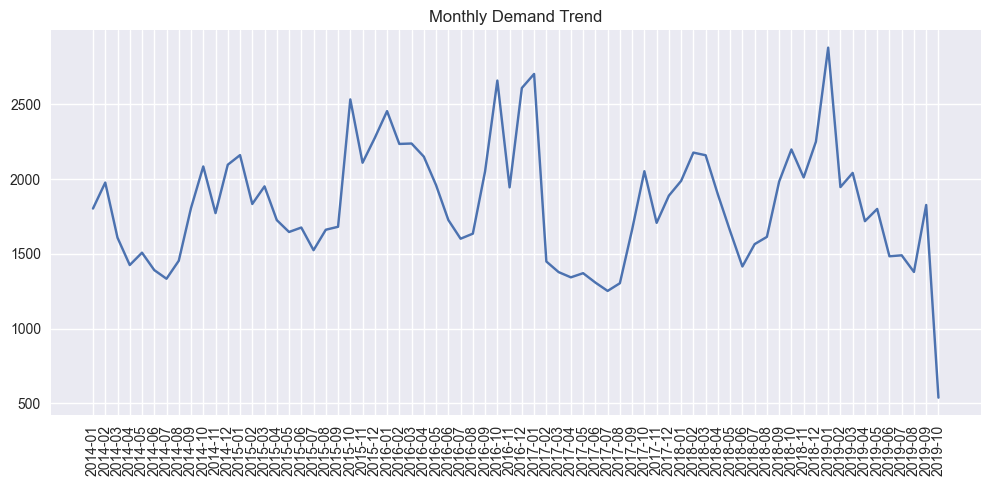

In [32]:
plt.figure(figsize=(12,5))
plt.plot(monthly["year_month"].astype(str), monthly["units_sold"])
plt.xticks(rotation=90)
plt.title("Monthly Demand Trend")
plt.show()

Weekday pattern

In [33]:
weekday = df.groupby("Weekday Name")["units_sold"].mean()
print(weekday.head())

weekday = weekday.reindex([
    "Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"
])
print(weekday.head())

Weekday Name
Friday      8.656082
Monday      8.817214
Saturday    9.508222
Sunday      9.209929
Thursday    8.466497
Name: units_sold, dtype: float64
Weekday Name
Monday       8.817214
Tuesday      8.614805
Wednesday    8.527604
Thursday     8.466497
Friday       8.656082
Name: units_sold, dtype: float64


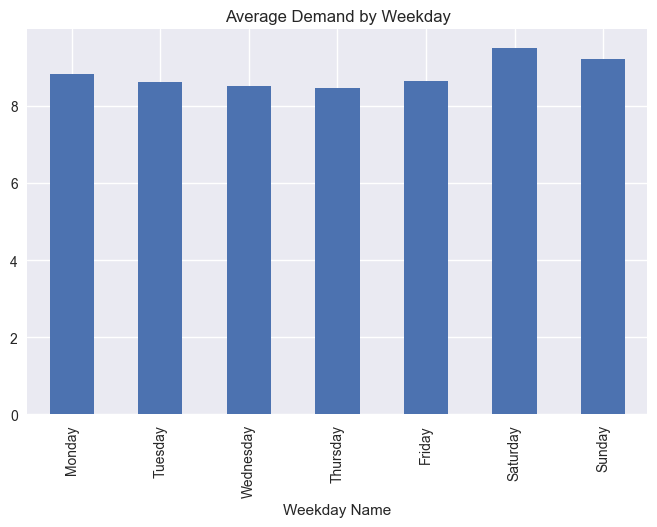

In [34]:
plt.figure(figsize=(8,5))
weekday.plot(kind="bar")
plt.title("Average Demand by Weekday")
plt.show()


Product trend comparison

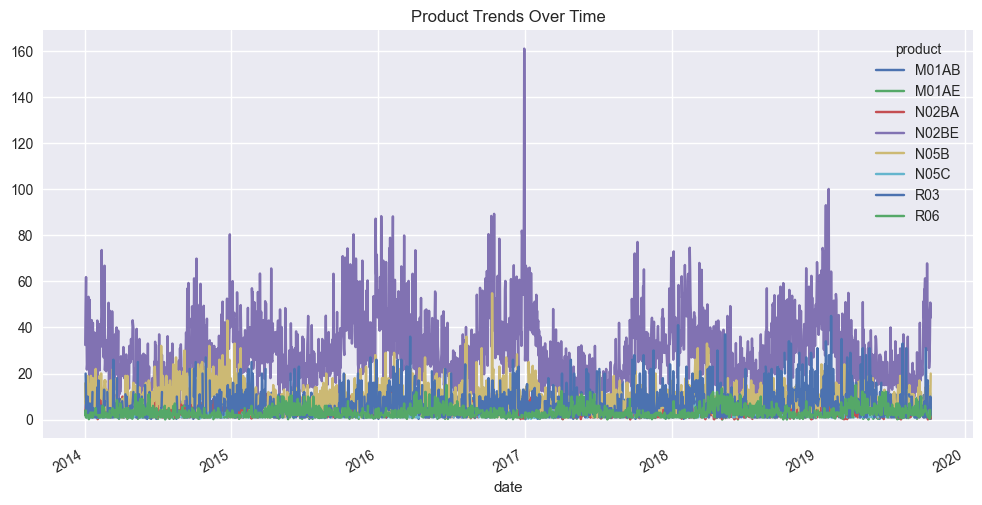

In [35]:
pivot = df.pivot_table(index="date", columns="product", values="units_sold", aggfunc="sum")

pivot.plot(figsize=(12,6))
plt.title("Product Trends Over Time")
plt.show()

Correlation heatmap

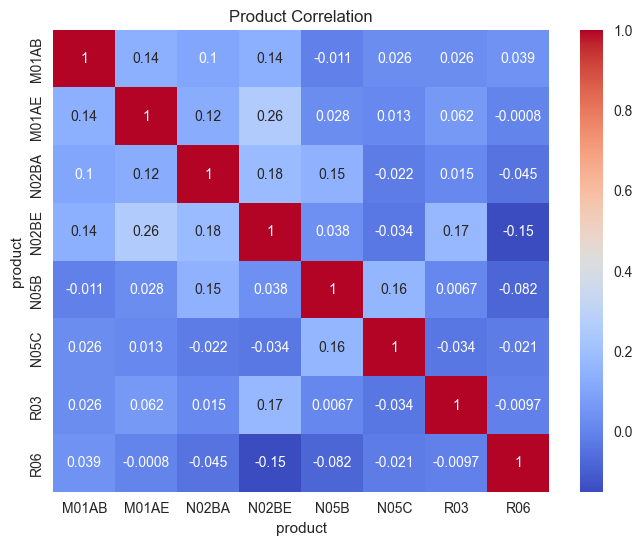

In [36]:
corr = pivot.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Product Correlation")
plt.show()


Outlier detection

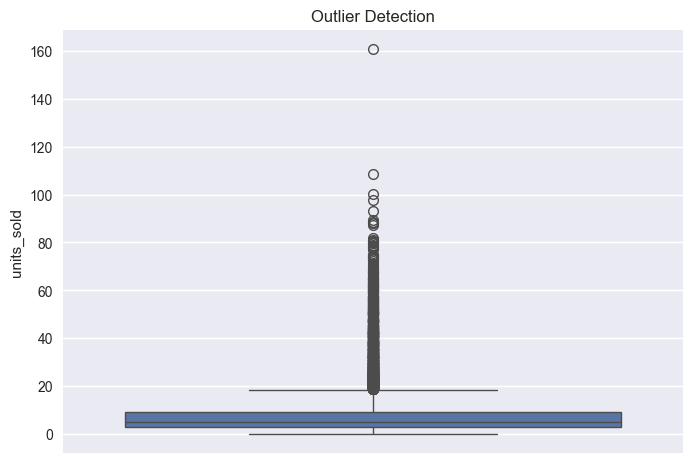

In [38]:
sns.boxplot(y=df["units_sold"])
plt.title("Outlier Detection")
plt.show()